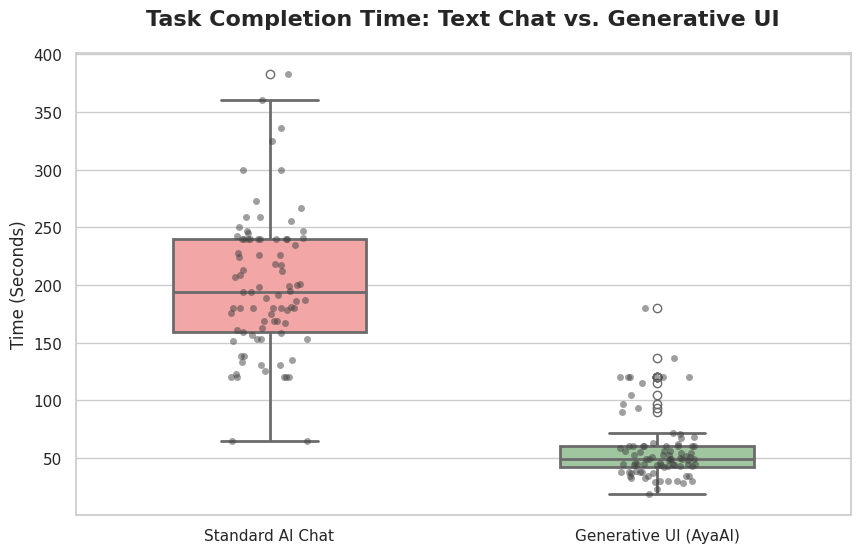

/tmp/ipykernel_879/2792566874.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Effort_Text', ax=axes[0], palette="Reds", order=likert_order)
/tmp/ipykernel_879/2792566874.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Effort_UI', ax=axes[1], palette="Greens", order=likert_order)


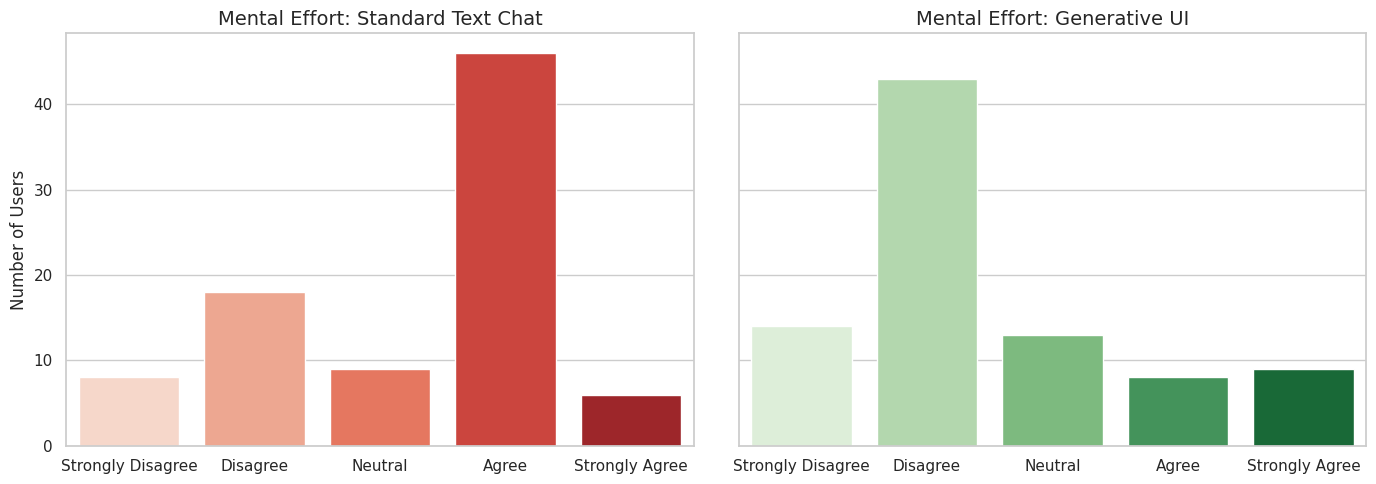

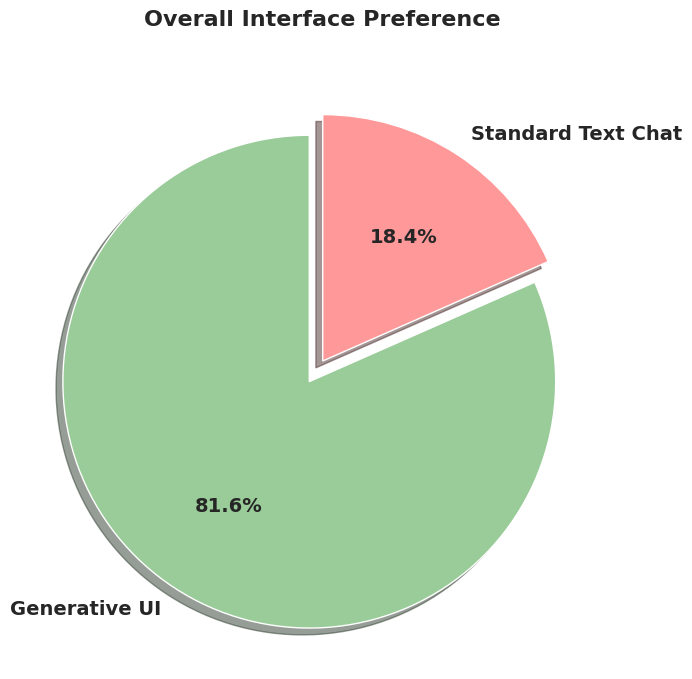


STATISTICAL ANALYSIS (T-TEST)
Average time with Text Chat:  199.5 seconds
Average time with Gen UI:     57.7 seconds
Time saved by users:          141.8 seconds on average!

P-value: 0.0000000000
✅ CONCLUSION: The difference is statistically significant! Your Generative UI is officially faster.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy import stats

# 1. ЗАГРУЗКА И ПЕРЕИМЕНОВАНИЕ ДАННЫХ
# Загружаем файл (убедись, что он загружен в Colab)
df = pd.read_csv('AyaAI - Form responses 1.csv')

# Переименовываем длинные столбцы в короткие технические названия для удобства
df.columns = [
    'Timestamp', 'Age', 'Status', 'AI_Frequency',
    'Effort_Text', 'Frustration_Text', 'Clarity_Text', 'Time_Text',
    'Effort_UI', 'Frustration_UI', 'Clarity_UI', 'Time_UI',
    'Preference', 'Reason'
]

# 2. ОЧИСТКА ДАННЫХ (DATA CLEANING) - ПРЕВРАЩАЕМ ТЕКСТ В СЕКУНДЫ
def parse_time_to_seconds(text):
    text = str(text).lower().replace(',', '.')

    # Ищем формат ММ:СС или ММ.СС (например, 2:18, 3.45)
    match_colon = re.search(r'(\d+)[:.](\d+)', text)
    if match_colon:
        return int(match_colon.group(1)) * 60 + int(match_colon.group(2))

    total_seconds = 0
    # Ищем минуты
    match_min = re.search(r'(\d+(?:\.\d+)?)\s*(?:m|min|minute)', text)
    # Ищем секунды
    match_sec = re.search(r'(\d+(?:\.\d+)?)\s*(?:s|sec|second)', text)

    if match_min:
        total_seconds += float(match_min.group(1)) * 60
    if match_sec:
        total_seconds += float(match_sec.group(1))

    if match_min or match_sec:
        return total_seconds

    # Если просто число без текста (например "186")
    numbers = re.findall(r'\d+', text)
    if numbers:
        val = float(numbers[0])
        if val < 10: return val * 60 # если ввели "3", скорее всего это минуты
        return val # если ввели "186", это секунды
    return np.nan

# Применяем функцию к нашим столбцам со временем
df['Time_Text_Sec'] = df['Time_Text'].apply(parse_time_to_seconds)
df['Time_UI_Sec'] = df['Time_UI'].apply(parse_time_to_seconds)

# 3. НАСТРОЙКА КРАСОТЫ ГРАФИКОВ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ==========================================
# ГРАФИК 1: Сравнение времени (Boxplot)
# ==========================================
plt.figure(figsize=(10, 6))
time_data = pd.DataFrame({
    'Standard AI Chat': df['Time_Text_Sec'],
    'Generative UI (AyaAI)': df['Time_UI_Sec']
})

ax = sns.boxplot(data=time_data, palette=['#FF9999', '#99CC99'], width=0.5, linewidth=2)
sns.stripplot(data=time_data, color=".25", size=5, alpha=0.5, jitter=True)
plt.title('Task Completion Time: Text Chat vs. Generative UI', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Time (Seconds)', fontsize=12)
plt.show()

# ==========================================
# ГРАФИК 2: Когнитивная нагрузка (Mental Effort)
# ==========================================
# Переводим текст в числа для графика
likert_order = ['Strongly Disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly Agree']
df['Effort_Text'] = pd.Categorical(df['Effort_Text'], categories=likert_order, ordered=True)
df['Effort_UI'] = pd.Categorical(df['Effort_UI'], categories=likert_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sns.countplot(data=df, x='Effort_Text', ax=axes[0], palette="Reds", order=likert_order)
axes[0].set_title('Mental Effort: Standard Text Chat', fontsize=14)
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Users')

sns.countplot(data=df, x='Effort_UI', ax=axes[1], palette="Greens", order=likert_order)
axes[1].set_title('Mental Effort: Generative UI', fontsize=14)
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# ==========================================
# ГРАФИК 3: Выбор пользователей (Pie Chart)
# ==========================================
plt.figure(figsize=(8, 8))
pref_counts = df['Preference'].value_counts()
colors = ['#99CC99', '#FF9999'] # Зеленый для твоего UI, красный для текста
explode = (0.1, 0) # Немного выдвинем кусок победителя

plt.pie(pref_counts, labels=['Generative UI', 'Standard Text Chat'], autopct='%1.1f%%',
        startangle=90, colors=colors, explode=explode, textprops={'fontsize': 14, 'weight': 'bold'}, shadow=True)
plt.title('Overall Interface Preference', fontsize=16, fontweight='bold', pad=20)
plt.show()

# ==========================================
# 4. НАУЧНЫЙ ТЕСТ (T-Test)
# ==========================================
print("\n" + "="*50)
print("STATISTICAL ANALYSIS (T-TEST)")
print("="*50)

mean_text = df['Time_Text_Sec'].mean()
mean_ui = df['Time_UI_Sec'].mean()

print(f"Average time with Text Chat:  {mean_text:.1f} seconds")
print(f"Average time with Gen UI:     {mean_ui:.1f} seconds")
print(f"Time saved by users:          {mean_text - mean_ui:.1f} seconds on average!\n")

# Проводим T-тест (очищаем от пустых значений на всякий случай)
t_stat, p_val = stats.ttest_ind(df['Time_Text_Sec'].dropna(), df['Time_UI_Sec'].dropna())

print(f"P-value: {p_val:.10f}")
if p_val < 0.05:
    print("✅ CONCLUSION: The difference is statistically significant! Your Generative UI is officially faster.")
else:
    print("❌ CONCLUSION: No significant difference found.")
print("="*50 + "\n")